<a href="https://colab.research.google.com/github/shubhagrawal8999/self-aprtice-agents-/blob/main/week4_langraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain_openai
from typing import Annotated
from langgraph.graph import StateGraph ,START,END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image ,display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [3]:
nouns =["Cabbages","unicons","Toasters","Penguins","bananas","Zombies"]
adjectives =["outrageous","smelly","pedantic","existential","moody"]


In [4]:
def shout(text:Annotated[str,"something to be shouted"]) ->str:
  print(text.upper())
  return text.upper()

shout("Hello")


HELLO


'HELLO'

In [5]:
class State(BaseModel):
  messages: Annotated[list,add_messages]


In [9]:
graph_builder =StateGraph(State)


In [16]:
def our_first_node(old_state:State)-> State:

    reply =f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role":"assistant","content":reply}]

    new_state =State(messages=messages)

    return new_state



graph_builder.add_node("first_node",our_first_node)

In [11]:
graph_builder.add_edge(START,"first_node")
graph_builder.add_edge("first_node",END)


In [18]:
graph = graph_builder.compile()

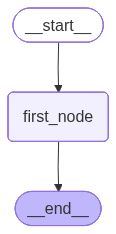

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))


In [20]:
def chat(user_input:str,history):
  message ={"role":"user","content":user_input}
  messages =[message]
  state =State(messages=messages)
  result = graph.invoke(state)
  print(result)
  return  result["messages"][-1].content


gr.ChatInterface(chat,type="messages").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae16a09f24d87ee5b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:

class State(BaseModel):
  messages: Annotated[list,add_messages]


In [24]:
graph_builder = StateGraph(State)

In [25]:
from google.colab import userdata
llm = ChatOpenAI(model="gpt-4o-mini",api_key=userdata.get('openai_api_key'))

def chatbot_node(old_state:State) ->State:
  response =llm.invoke(old_state.messages)
  new_state = State(messages=[response])
  return new_state

graph_builder.add_node("chatbot",chatbot_node)


In [26]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)


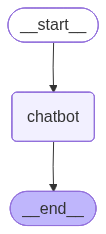

In [28]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
def chat(user_input:str ,history):
    initial_state =State(messages=[{"role":"user","content":user_input}])
    result=graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content

gr.ChatInterface(chat,type="messages").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://85db28ed53daec3004.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
